# Project: Diabetes Detection System
*Submited By: Selim Ahmed*<br/>
AI Engineering (Batch - 1)



## Step 1: Import Libraries

In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Library - Handle Unbalanced Data
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

# Library - Dataset Train Test Split
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Library - Classification Algorithm
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
#-------------------------------
# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
#-------------------------------

# Library - Build Model
import joblib

## Step 2: Load Dataset from github

In [190]:
url = "https://raw.githubusercontent.com/aronno1920/AI-Engineering/main/Assignment/diabete-dataset.csv"
data = pd.read_csv(url)

## Step 3: Basic Data Cleaning

In [191]:
# Display the first 5 rows
print("Show Top 5 rows:\n", data.head())

Show Top 5 rows:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [192]:
# Show concise summary of the DataFrame, including column data types and non-null counts
print("\nShow Dataset structure:", data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Show Dataset structure: None


In [193]:
# Display statistical summary (count, mean, std, min, max, etc.) for numeric columns
print("\nShow Data Description:\n", data.describe())


Show Data Description:
        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0

In [194]:
# Show total number of missing values in each column
print("\nShow Null Values Count in Each Column:\n", data.isnull().sum())


Show Null Values Count in Each Column:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [195]:
# Show Outcome to check data is imbalanced or not
data["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


## Step 4: Exploratory Data Analysis (EDA)

EDA base on feature over Outcome

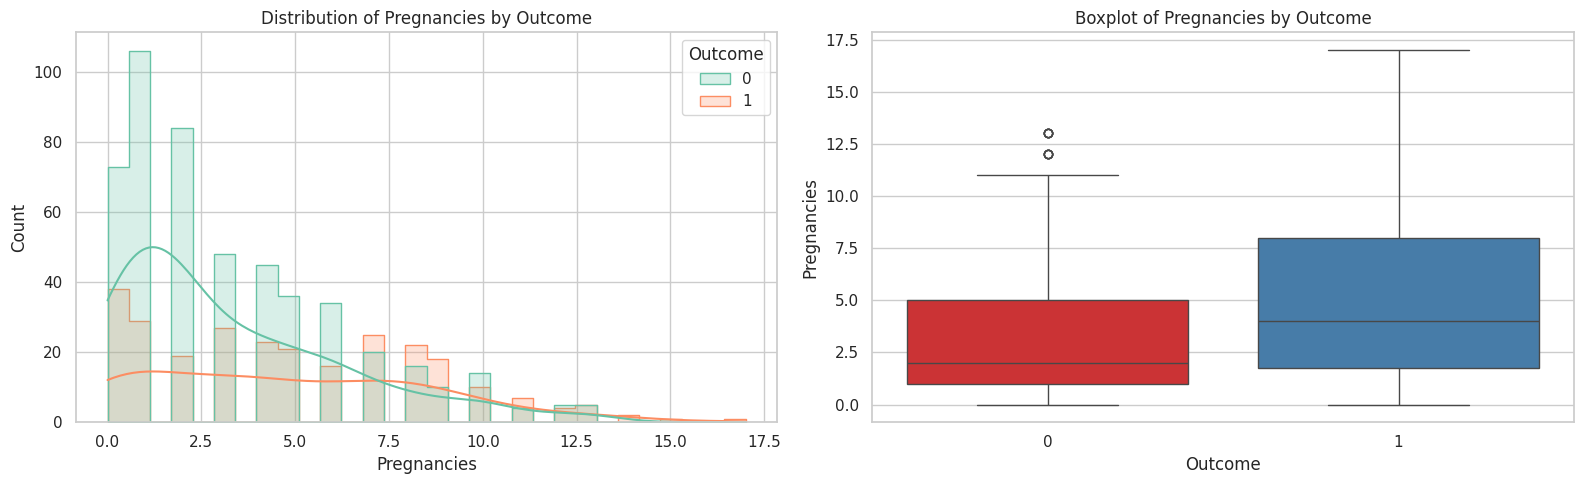

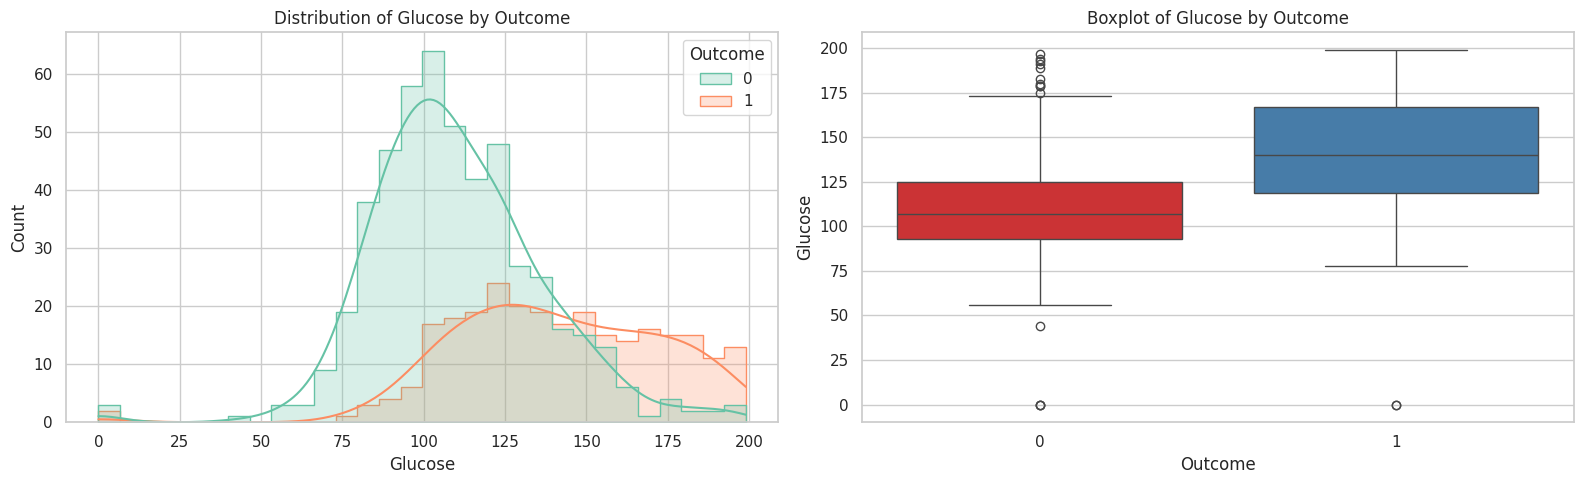

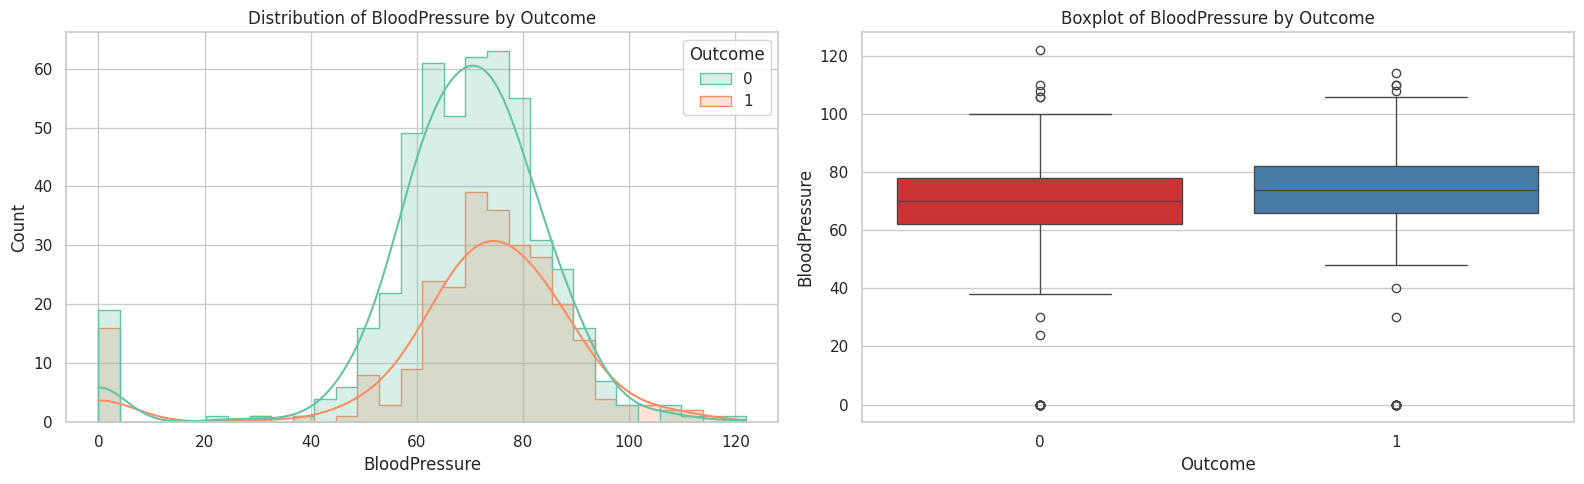

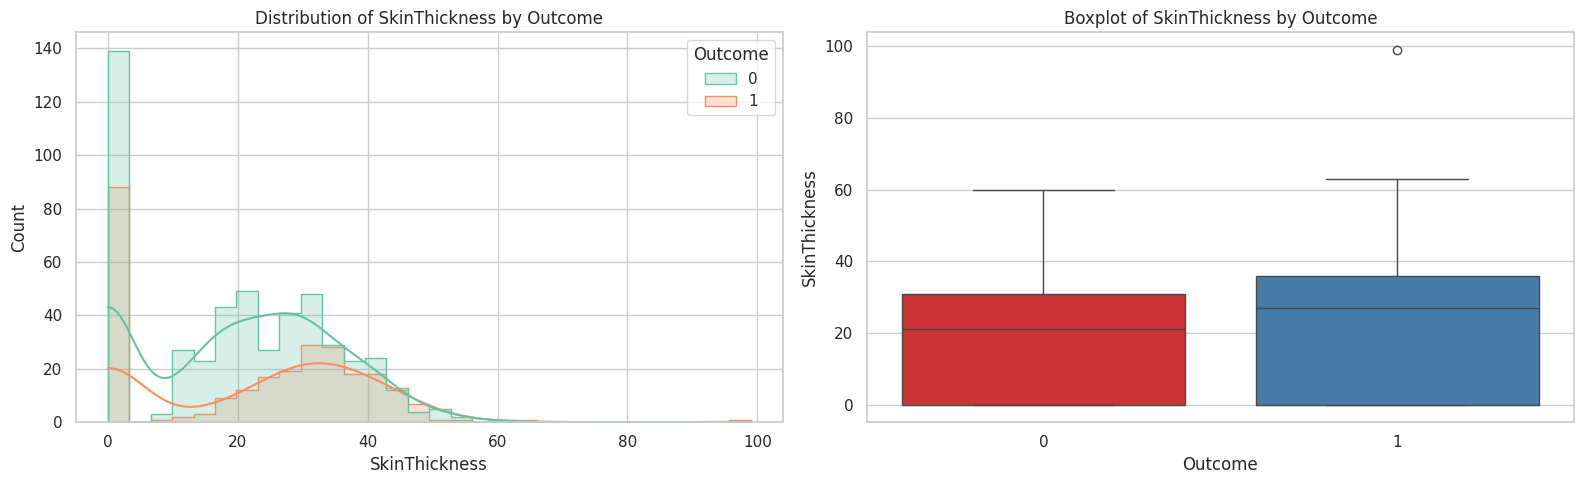

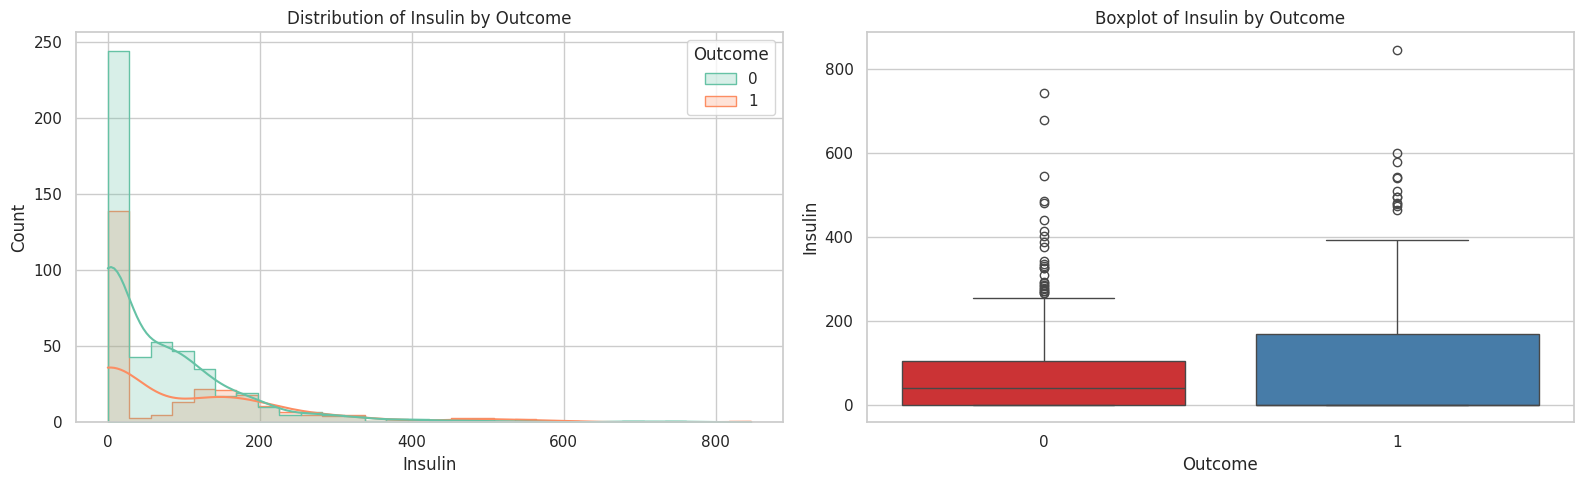

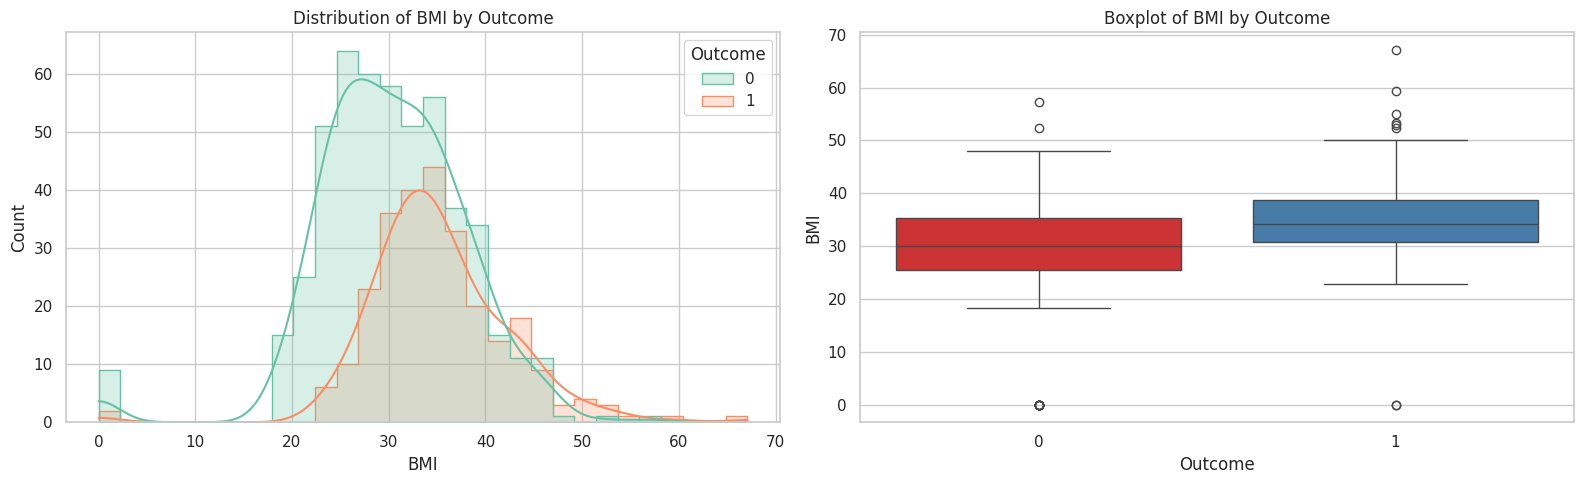

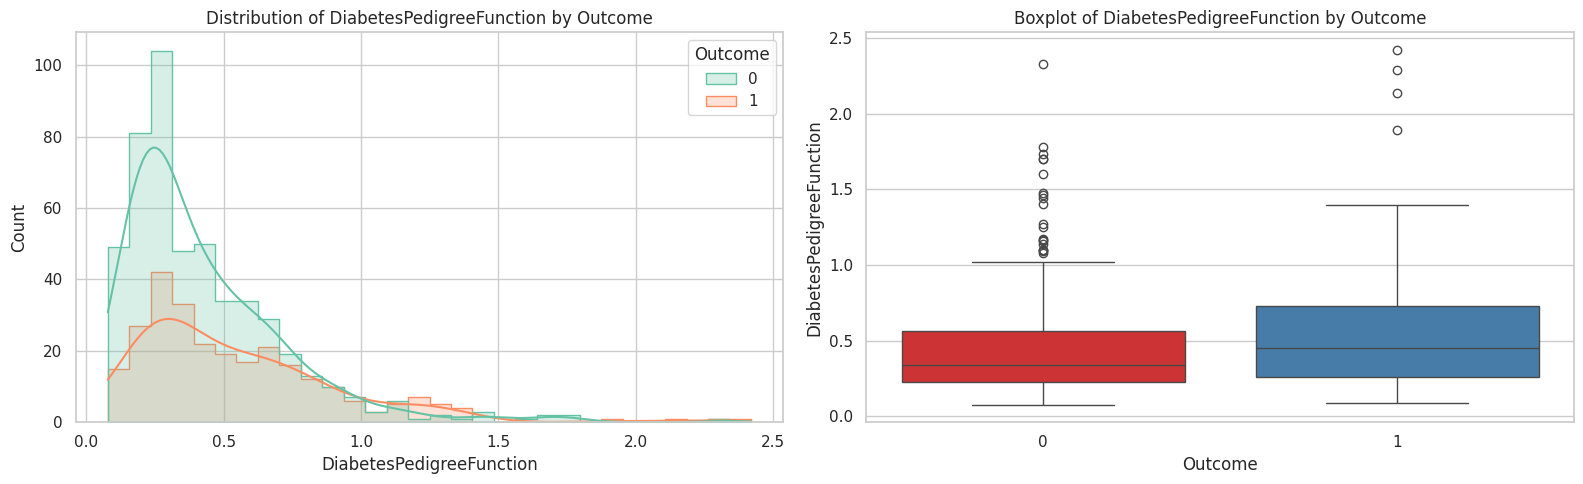

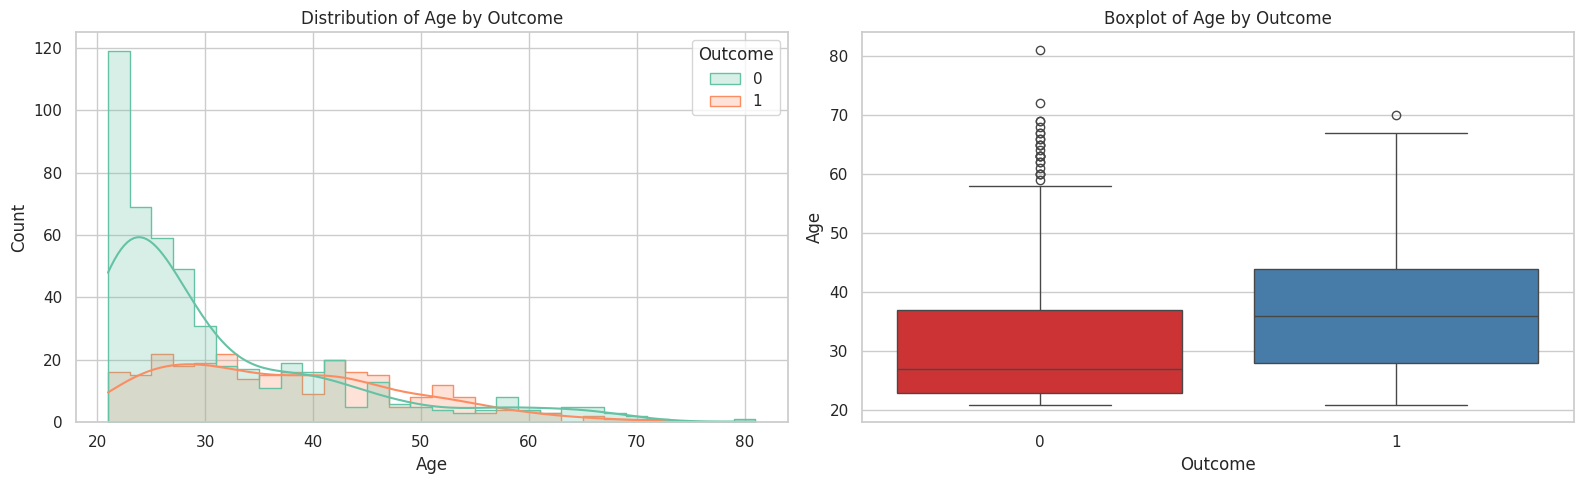

In [196]:
# Set style
sns.set(style="whitegrid")

# List of features (excluding Outcome)
features = [col for col in data.columns if col != 'Outcome']

# Iterate over each feature
for feature in features:
    plt.figure(figsize=(16, 5))

    # Histogram: Feature distribution by Outcome
    plt.subplot(1, 2, 1)
    sns.histplot(data, x=feature, hue="Outcome", kde=True, bins=30, palette="Set2", element="step")
    plt.title(f"Distribution of {feature} by Outcome")

    # Boxplot: See spread and outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x="Outcome", y=feature, data=data, hue="Outcome", palette="Set1")
    plt.title(f"Boxplot of {feature} by Outcome")
    plt.legend([], [], frameon=False)  # Hide legend

    plt.tight_layout()
    plt.show()

Heatmap Correlation base on feature over Outcome (Separeted)

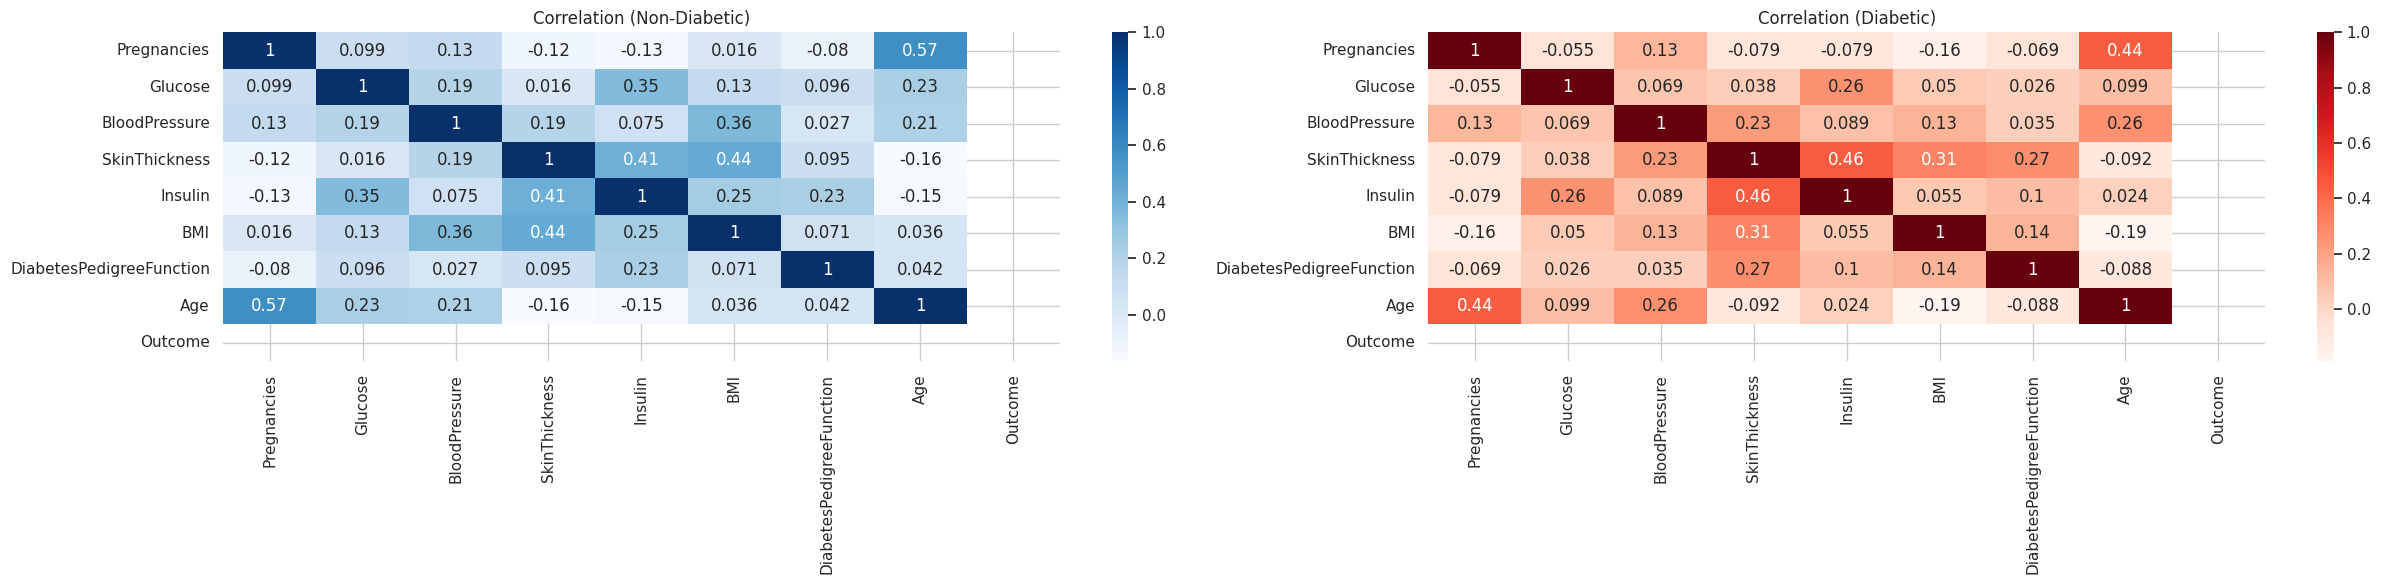

In [197]:
# Correlation matrix for diabetics only
diabetic_corr = data[data["Outcome"] == 1].corr()
non_diabetic_corr = data[data["Outcome"] == 0].corr()

# Plot
plt.figure(figsize=(25, 6))

plt.subplot(1, 2, 1)
sns.heatmap(non_diabetic_corr, annot=True, cmap='Blues')
plt.title("Correlation (Non-Diabetic)")

plt.subplot(1, 2, 2)
sns.heatmap(diabetic_corr, annot=True, cmap='Reds')
plt.title("Correlation (Diabetic)")

plt.tight_layout()
plt.show()


Heatmap Correlation base on feature over Outcome

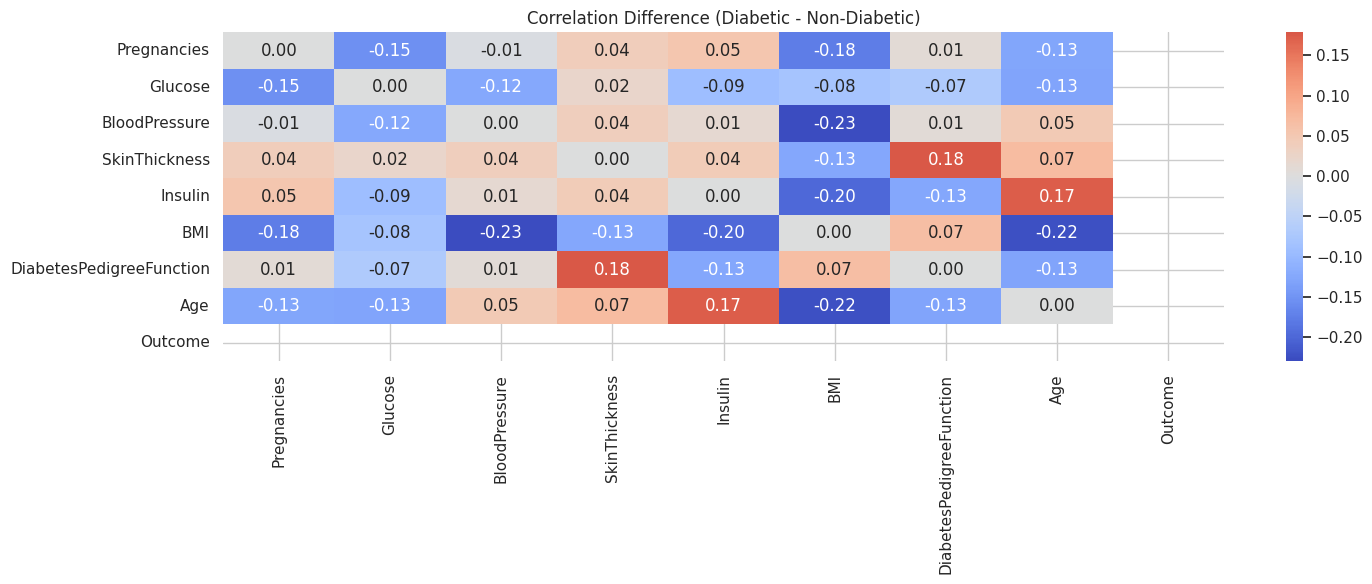

In [198]:
diabetic_corr = data[data["Outcome"] == 1].corr()
non_diabetic_corr = data[data["Outcome"] == 0].corr()

# Difference in correlations
corr_diff = diabetic_corr - non_diabetic_corr

# Plot single heatmap of the differences
plt.figure(figsize=(15, 6))
sns.heatmap(corr_diff, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation Difference (Diabetic - Non-Diabetic)")
plt.tight_layout()
plt.show()


## Step 5: Train-Test Split

In [199]:
x = data.drop('Outcome', axis=1)
y = data['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

# Feature scaling (important before SMOTE if distance-based models used)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# Convert back to DataFrame for better readability (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=x_train.columns, index=x_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=x_test.columns, index=x_test.index)

print(f"\nScaled Training Data with Shape: ", X_train_scaled.shape)
display(X_train_scaled.head())

print(f"\nScaled Test Data with Shape: ", X_test_scaled.shape)
display(X_test_scaled.head())
print('\n------------------------------------------------------------\n')


# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

joblib.dump(scaler, "scaler.pkl")


# Check the class distribution after SMOTE
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))


Scaled Training Data with Shape:  (614, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,-0.851355,-0.980131,-0.404784,-0.553973,-0.331319,-0.607678,0.310794,-0.792169
711,0.356576,0.161444,0.465368,0.392787,-0.526398,-0.302139,-0.116439,0.561034
373,-0.549372,-0.504474,-0.622322,1.213312,0.142444,0.372594,-0.764862,-0.707594
46,-0.851355,0.795653,-0.731091,-1.311380,-0.730766,-0.289408,0.262314,-0.369293
682,-1.153338,-0.821579,-0.296015,1.150195,0.244628,1.607482,-0.337630,-0.961320



Scaled Test Data with Shape:  (154, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,0.960541,1.207888,-0.296015,-1.311380,-0.730766,-0.582217,-0.555791,0.561034
672,1.866489,-1.677760,1.988135,0.140318,-0.275582,0.448979,-0.583061,1.153060
700,-0.549372,0.034603,0.356599,0.392787,1.127127,0.499902,0.016882,-0.623019
630,0.960541,-0.219081,-0.296015,-1.311380,-0.730766,-0.582217,0.771356,0.053583
81,-0.549372,-1.487497,-3.776623,-1.311380,-0.730766,-4.070459,-1.137554,-0.961320



------------------------------------------------------------

Before SMOTE: Counter({0: 400, 1: 214})
After SMOTE: Counter({0: 400, 1: 400})


Model data fit and print accuracy_score & classification_report

In [200]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Stochastic Gradient Descent": SGDClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}


results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Precision": round(report["weighted avg"]["precision"], 4),
        "Recall": round(report["weighted avg"]["recall"], 4),
        "F1-Score": round(report["weighted avg"]["f1-score"], 4),
        "Accuracy": round(acc, 4)
    })


results_df = pd.DataFrame(results)
print(results_df)

                         Model  Precision  Recall  F1-Score  Accuracy
0          Logistic Regression     0.7065  0.7143    0.7084    0.7143
1          K-Nearest Neighbors     0.6946  0.7013    0.6969    0.7013
2                Decision Tree     0.7108  0.7208    0.7102    0.7208
3                Random Forest     0.7546  0.7597    0.7555    0.7597
4  Stochastic Gradient Descent     0.7349  0.7338    0.7343    0.7338
5            Gradient Boosting     0.7483  0.7532    0.7496    0.7532
6                     AdaBoost     0.7894  0.7922    0.7902    0.7922
7                  Extra Trees     0.7423  0.7468    0.7437    0.7468
8       Support Vector Machine     0.7497  0.7532    0.7509    0.7532
9                  Naive Bayes     0.7179  0.7078    0.7114    0.7078


## Step 6: Model Evaluate - Confusion Matrix & ROC

### Confusion Matrix

In [201]:
def plot_conf_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Confusion Matrix (Logistic Regression)):
 [[82 18]
 [26 28]]


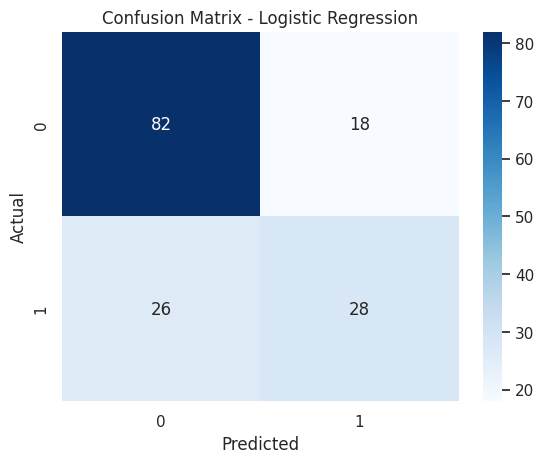


Confusion Matrix (K-Nearest Neighbors)):
 [[80 20]
 [26 28]]


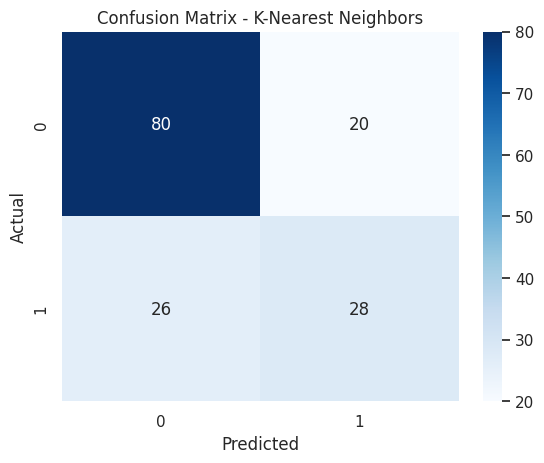


Confusion Matrix (Decision Tree)):
 [[85 15]
 [28 26]]


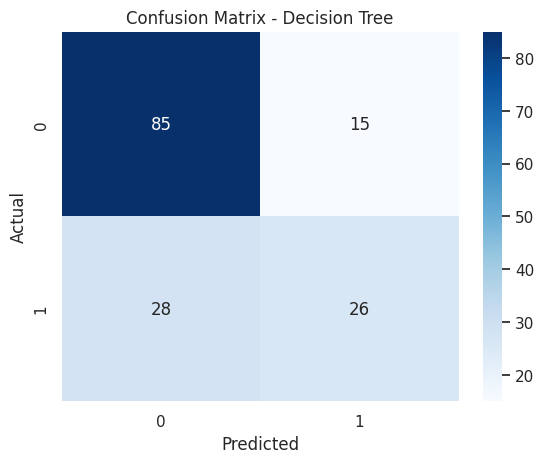


Confusion Matrix (Random Forest)):
 [[85 15]
 [22 32]]


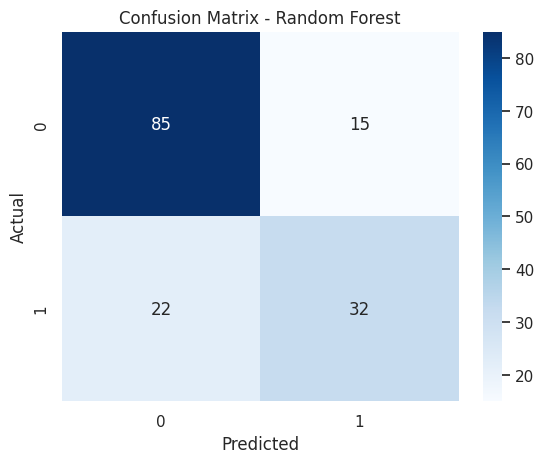


Confusion Matrix (Stochastic Gradient Descent)):
 [[79 21]
 [20 34]]


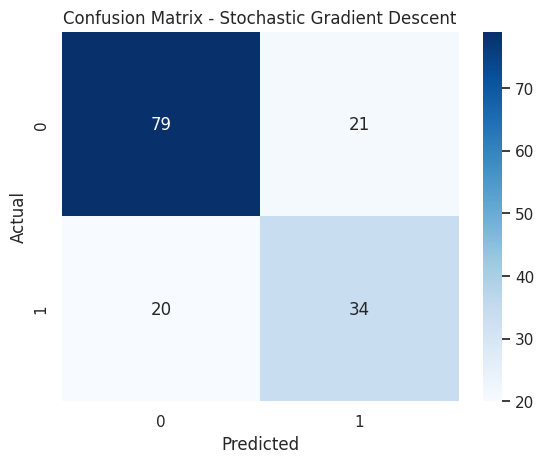


Confusion Matrix (Gradient Boosting)):
 [[84 16]
 [22 32]]


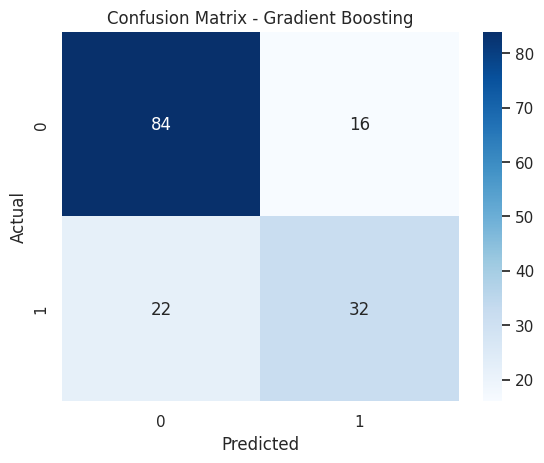


Confusion Matrix (AdaBoost)):
 [[86 14]
 [18 36]]


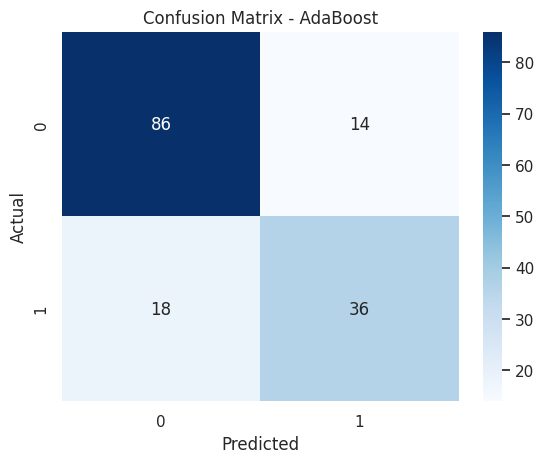


Confusion Matrix (Extra Trees)):
 [[83 17]
 [22 32]]


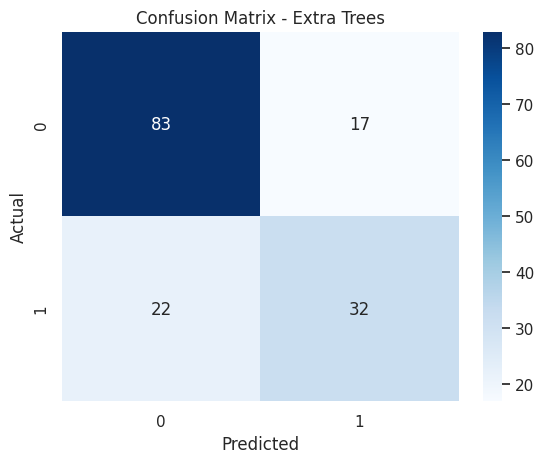


Confusion Matrix (Support Vector Machine)):
 [[83 17]
 [21 33]]


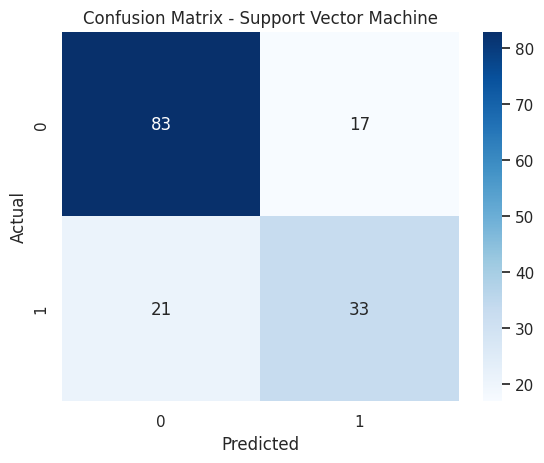


Confusion Matrix (Naive Bayes)):
 [[74 26]
 [19 35]]


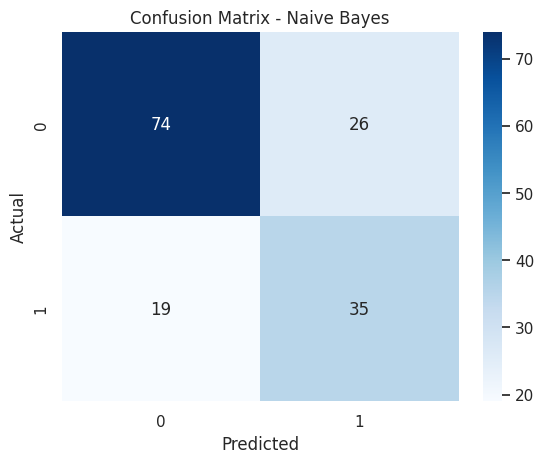

In [202]:
for name, model in models.items():
  y_pred_log = model.predict(X_test_scaled)
  cm_log = confusion_matrix(y_test, y_pred_log)

  print(f"\nConfusion Matrix ({name})):\n", cm_log)
  plot_conf_matrix(y_test, y_pred_log, name)

### ROC AUC

In [203]:
def evaluate_model(model, X_test, y_test, model_name, scaled=True):
    # Make predictions
    y_pred = model.predict(X_test)

    # Some models do not have predict_proba; use decision_function or fallback
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        # Convert decision scores to probability-like values using min-max scaling
        decision_scores = model.decision_function(X_test)
        y_prob = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min() + 1e-8)
    else:
        print(f"{model_name} does not support probability or decision function.")
        return

    # ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')


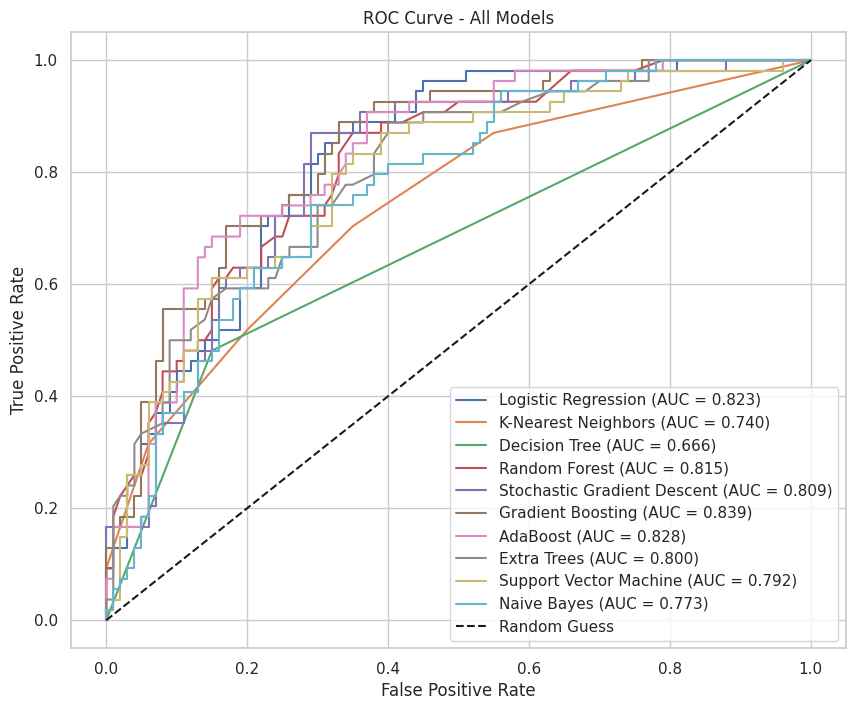

In [204]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    evaluate_model(model, X_test_scaled, y_test, model_name=name, scaled=True)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Step 7: Final Output

In [205]:
for name, model in models.items():
  print("Model: ", name)

Model:  Logistic Regression
Model:  K-Nearest Neighbors
Model:  Decision Tree
Model:  Random Forest
Model:  Stochastic Gradient Descent
Model:  Gradient Boosting
Model:  AdaBoost
Model:  Extra Trees
Model:  Support Vector Machine
Model:  Naive Bayes


In [206]:
joblib.dump(models["Random Forest"], 'diabetes_model.pkl')

['diabetes_model.pkl']

## Step 8: Test Model with Unknown Data

In [207]:
# Feature columns
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

#Data From Training Model
#new_data = pd.DataFrame([[6,148,72,35,0,33.6,0.627,50]], columns=features)      # Diabetes
#new_data = pd.DataFrame([[5,116,74,0,0,25.6,0.201,30]], columns=features)      # No Diabetes

# New data as DataFrame
#new_data = pd.DataFrame([[2, 20, 70, 25, 90, 32.0, 0.4, 35]], columns=features)
new_data = pd.DataFrame([[2, 80, 70, 35, 50, 35.0, 0.6, 45]], columns=features)
#new_data = pd.DataFrame([[2, 50, 25, 35, 80, 40.0, 1.2, 52]], columns=features)

In [208]:
# Load scaler and model
scaler = joblib.load("scaler.pkl")
model = joblib.load("diabetes_model.pkl")

# Scale and convert back to DataFrame with same columns
new_data_scaled = scaler.transform(new_data)
new_data_scaled_df = pd.DataFrame(new_data_scaled, columns=features)

# Predict
prediction = model.predict(new_data_scaled_df)
proba = model.predict_proba(new_data_scaled_df)[0][1]

# Output
print("Prediction:", "Diabetes" if prediction[0] == 1 else "No Diabetes")
print(f"Probability of Diabetes: {proba:.2%}")

Prediction: No Diabetes
Probability of Diabetes: 35.00%
